# ARTI 403 – Image Processing
## STUDENT PROCEDURAL MANUAL – Lab 2

## Step#1: Import the libraries

In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def show(img, title=''):
    """Displays an image inside the notebook (PIL's .show() opens an
    external viewer and shows nothing in Jupyter)."""
    plt.figure(figsize=(4, 4))
    plt.imshow(np.asarray(img), cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

## Step#2: Define Functions

In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                               interpolation=cv2.INTER_NEAREST)
    return sampled_image

In [3]:
def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

In [4]:
def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

## Step#3: Import the image and set the parameters

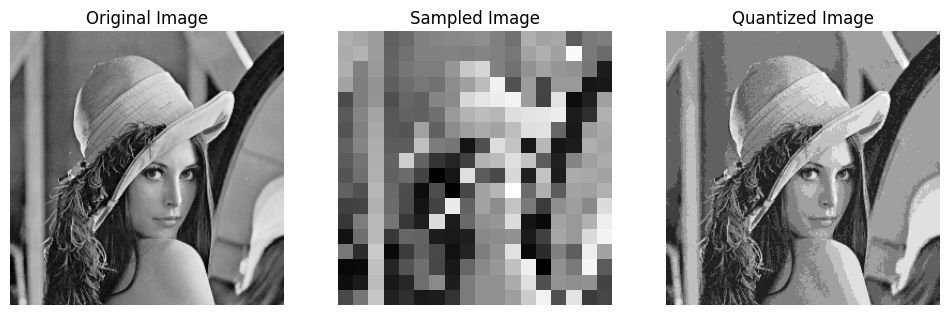

In [5]:
image_path = 'lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

## Arithmetic Operations

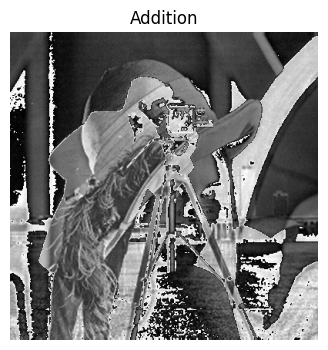

In [6]:
img1 = Image.open('lena_gray_256.tif')
img2 = Image.open('cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
show(addition, 'Addition')

## Sets and Logical Operations

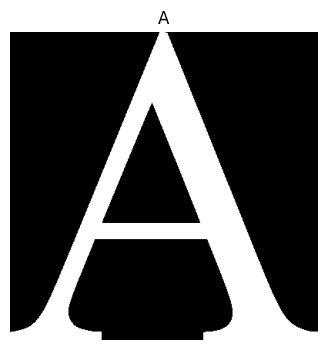

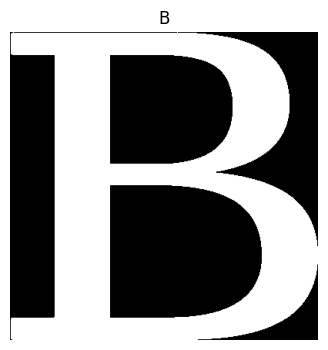

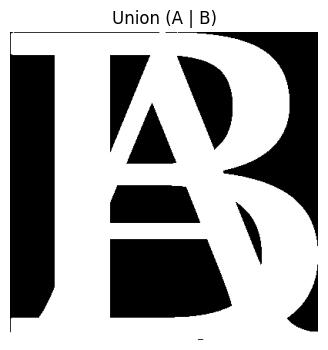

In [7]:
def load_shape(path, size=(400, 400)):
    """Loads a PNG with transparency as a binary (0/255) image."""
    img = Image.open(path)
    mask = img.getchannel('A') if 'A' in img.mode else img.convert('L')
    mask = mask.resize(size, Image.Resampling.LANCZOS)
    return np.where(np.asarray(mask) > 127, 255, 0).astype(np.uint8)

im3arr = load_shape('A.png')
im4arr = load_shape('B.png')

show(im3arr, 'A')
show(im4arr, 'B')

union = im4arr | im3arr
show(union, 'Union (A | B)')

# Tasks

## Task#1: Change the sampling and quantization parameters and observe the effects

Sampling factor = 2, Quantization levels = 64


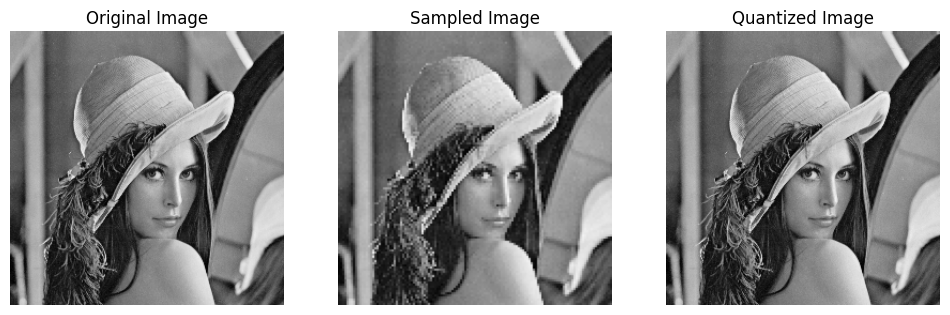

Sampling factor = 4, Quantization levels = 16


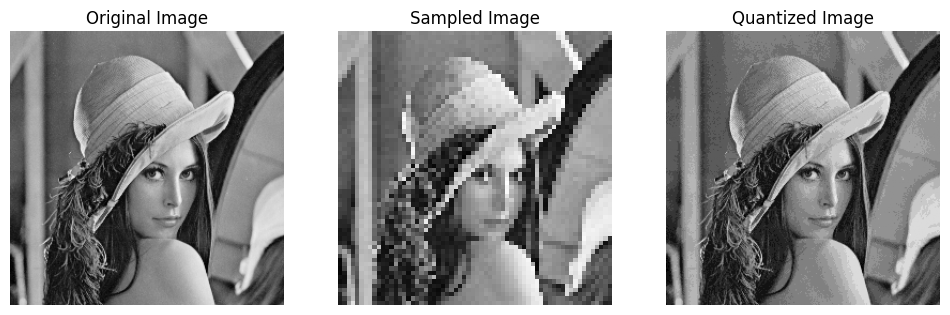

Sampling factor = 8, Quantization levels = 9


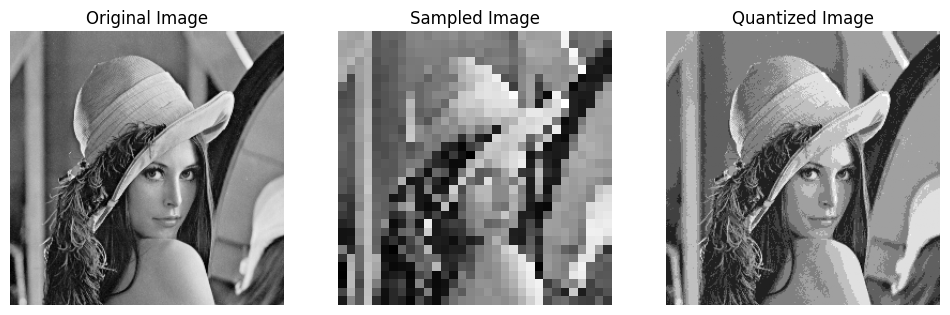

Sampling factor = 14, Quantization levels = 4


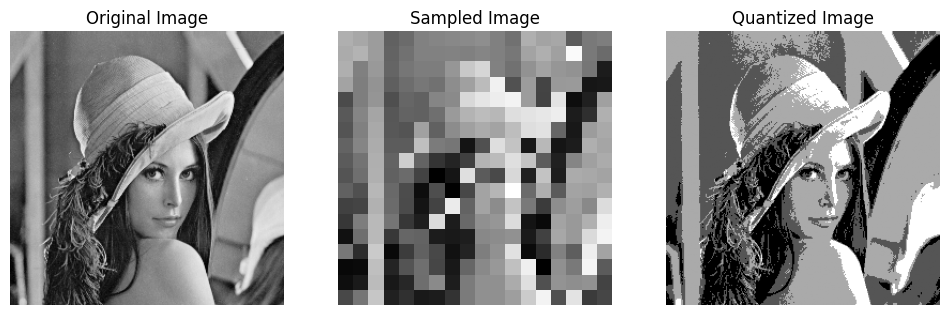

Sampling factor = 20, Quantization levels = 2


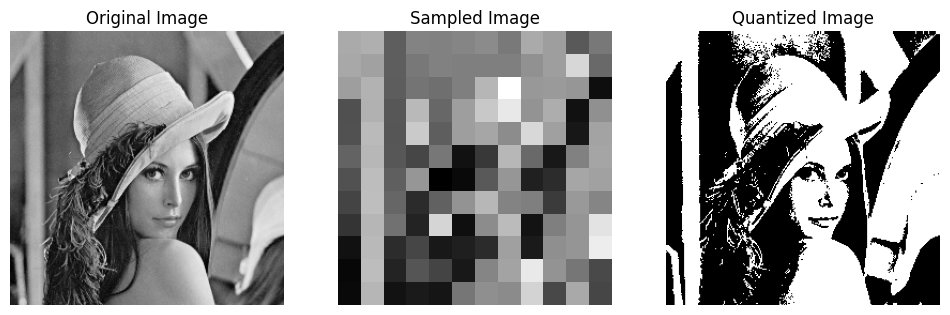

In [8]:
image_path = 'lena_gray_256.tif'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Try different combinations of sampling factor and quantization levels
parameter_sets = [
    (2, 64),
    (4, 16),
    (8, 9),
    (14, 4),
    (20, 2),
]

for factor, levels in parameter_sets:
    sampled_image = sample_image(original_image, factor)
    quantized_image = quantize_image(original_image, levels)
    print(f"Sampling factor = {factor}, Quantization levels = {levels}")
    plot_images(original_image, sampled_image, quantized_image)

## Task#2: Read two images, convert them into arrays, and perform the following operations on them

### Read the two images and convert them into arrays

In [9]:
img1 = Image.open('lena_gray_256.tif')
img2 = Image.open('cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

### 2.1 Subtract two images and display the result

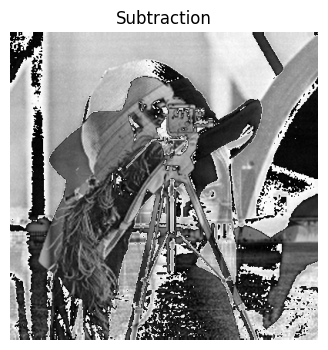

In [10]:
subtraction = im1arr - im2arr
show(subtraction, 'Subtraction')

### 2.2 Add one image with a constant value of 175 and display it

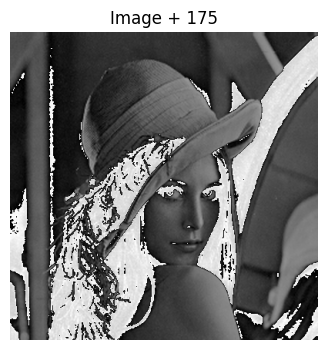

In [11]:
constant_value = 175
addition_const = im1arr + constant_value
show(addition_const, 'Image + 175')

### 2.3 Apply the set difference operation on two Gray-Scale images

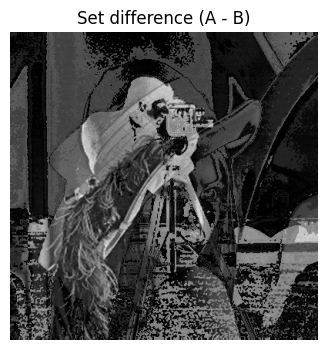

In [12]:
set_difference = im1arr & ~im2arr
show(set_difference, 'Set difference (A - B)')

### 2.4 Apply the symmetric difference operation on two Gray-Scale images

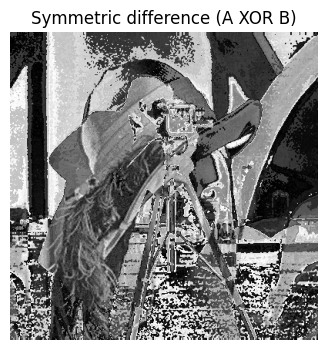

In [13]:
symmetric_difference = im1arr ^ im2arr
show(symmetric_difference, 'Symmetric difference (A XOR B)')

### 2.5 Apply Intersection operations on two Gray-Scale images

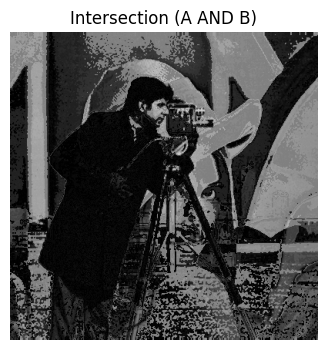

In [14]:
intersection = im1arr & im2arr
show(intersection, 'Intersection (A AND B)')